In [1]:
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import torch
import torch.nn as nn
import numpy as np
import os
from PIL import Image, ImageDraw
import zarr
from tqdm.notebook import tqdm
import json
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.filters import frangi , hessian , meijering
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import cv2
import segmentation_models_pytorch as smp
from torchview import draw_graph
import albumentations as A

In [2]:
@torch.no_grad()
def read_images(base_path, part,preprocessor,in_c,resize_binary,
                max_workers=None,train_class_counts=None,k=40,just_binary_trining=False,resizer=None,rare=None):
    base_path = Path(base_path)
    images_base = base_path / "images" / part
    labels_base = base_path / "labels" / part
    skels_base = base_path / "skels" / part
    transformed_base = base_path / "transformed" / part
    
    with open(f"../data/{part}_side_labels.json","r") as f:
        side_labels = json.load(f)
    with open(f"../data/{part}_fg_bboxes.json","r") as f:
        bboxes = json.load(f)
    with open(f"../data/{part}.json","r") as f:
        metadata = json.load(f)
    if(train_class_counts is not None):
        freqs = train_class_counts / train_class_counts.sum()
        class_w = 1 / (freqs + 1e-6)
        class_w[0] = 0
    image_names = sorted([p.name for p in os.scandir(images_base) if p.is_file()])
    if(train_class_counts is not None):
        max_count = np.max(train_class_counts[1:])
        print("max count is : ",max_count)
    if(not preprocessor):
        print("NOTE : preprocessor is not defined . no preprocessing will be used !")
    def _read_one(fname):
        name_stem = Path(fname).stem
        img_path = images_base / fname
        label_path = labels_base / f"{name_stem}.zarr"
        t_img_path = transformed_base / f"{name_stem}.zarr"
        skel_path = skels_base / fname
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        # t_img = zarr.load(t_img_path)
        if(preprocessor):
            for p in preprocessor:
                img = p(img)

        if(in_c!=1):
            # img = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
            img = np.stack([img, img, img], axis=-1)
            # t_img = np.stack([t_img, t_img, t_img], axis=-1)*255

        label = zarr.load(str(label_path))
        if(train_class_counts is not None):
            num_classes = class_w.shape[0]
            counts = np.bincount(label.reshape(-1), minlength=num_classes)
            weight = float((counts * class_w).sum())
        else:
            weight = None

        unique_labels = np.unique(label)
        unique_labels = unique_labels[unique_labels!=0]

        binary_label = (label!=0).astype(np.uint8)
        side_label = side_labels[name_stem]
        bbox = bboxes[name_stem]
        all_bboxes = metadata[name_stem]["bbox_norm"]
        all_labels = metadata[name_stem]["labels"]
        return img, label ,binary_label,bbox, weight , side_label , all_bboxes , all_labels , name_stem

    if max_workers is None:
        cpu = os.cpu_count() or 4
        max_workers = min(32, cpu * 4)

    results = []
    weights = []
    ls=[]
    co=0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for img, label ,binary_label,bbox, weight , side_label , all_bboxes , all_labels , name_stem  in tqdm(ex.map(_read_one, image_names), total=len(image_names)):
            if(part=="train"):
                current_results , current_weights ,flag=crop_around_rare(
                    img, 
                    label ,
                    binary_label,
                    bbox, 
                    weight , 
                    side_label ,
                    all_bboxes , 
                    all_labels,
                    name_stem,
                    rare,
                    resizer
                )
                if(flag):
                    ls.append(name_stem)
                co+=flag
            else:
                current_results = [[img, label ,binary_label,bbox,name_stem]]
                current_weights = [weight]
            results+=current_results
            weights+=current_weights

    print("f",co)

    if(train_class_counts is not None):
        weights = torch.tensor(weights).double()
        weights +=1e-8
        weights /=weights.sum()
        return results , weights
    else:
        return results
    
def crop_around_rare(img, label ,binary_label,bbox, weight , side_label ,all_bboxes , all_labels,name_stem,rare_labels,resizer):
    current_results = [[img, label ,binary_label,bbox,name_stem]]
    current_weights = [weight]
    flag=0
    for i,l in enumerate(all_labels):
        if l in rare_labels:
            rx_up = all_bboxes[i][0]
            ry_up = all_bboxes[i][1]
            rx_down = rx_up + all_bboxes[i][2]
            ry_down = ry_up + all_bboxes[i][3]

            tx_up = bbox[0]
            ty_up = bbox[1]
            tx_down = bbox[2]
            ty_down = bbox[3]

            x_up_margin = (rx_up - tx_up)//2
            y_up_margin = (ry_up - ty_up)//2
            x_down_margin = (tx_down - rx_down)//2
            y_down_margin = (ty_down - ry_down)//2

            rx_up = int(max(0,rx_up - x_up_margin))
            ry_up = int(max(0,ry_up - y_up_margin))
            rx_down = int(min(tx_down,rx_down + x_down_margin))
            ry_down = int(min(ty_down,ry_down + y_down_margin))
    
            # res = resizer(
            #     image=img[ry_up:ry_down,rx_up:rx_down,None],
            #     mask=label[ry_up:ry_down,rx_up:rx_down,None],
            #     binary_mask = binary_label[ry_up:ry_down,rx_up:rx_down,None]
            # )
            new_img = np.zeros_like(img)
            new_binary_label = np.zeros_like(binary_label)
            new_label = np.zeros_like(label)
            
            new_img[ry_up:ry_down,rx_up:rx_down] = img[ry_up:ry_down,rx_up:rx_down]
            new_binary_label[ry_up:ry_down,rx_up:rx_down]=binary_label[ry_up:ry_down,rx_up:rx_down]
            new_label[ry_up:ry_down,rx_up:rx_down]=label[ry_up:ry_down,rx_up:rx_down]

            
            current_results += [[new_img.copy(), new_label.copy() ,new_binary_label.copy(),[0,0,511,511],name_stem]]
            current_weights += [weight]
            flag=1
    
    return current_results,current_weights,flag

In [3]:
args = {
    "base_path": "../dataset/syntax",
    "in_c": 1,
    "base_channel": 32,
    "image_shape": [
        512,
        512
    ],
    "abs_class_count": 17,
    "attention": True,
    "k": 40,
    "batch_size": 10,
    "num_workers": 5,
    "device": "cuda",
    "lr": 0.0005,
    "momentum": 0.99,
    "crop_prob": 0,
    "weight_decay": 0.001,
    "epcohs": 10,
    "f_int_scale": 2,
    "full_report_cycle": 10,
    "max_channels": 512,
    "unet_depth": 6,
    "loss_type": "tversky loss",
    "alpha": 0.3,
    "beta": 0.7,
    "t_gamma": 2.0,
    "f_gamma": 2.0,
    "resize_binary": [
        True,
        [
            224,
            224
        ]
    ],
    "loss_coefs": {
        "CE": 1.0,
        "Second": 1.0
    },
    "swin_head": "costume",
    "swin_type": "swin_v2_s",
    "output_base_path": "./outputs",
    "name": "test",
    "deep_super_vision": True,
    "just_binary_trining": True,
    "use_sch": False,
    "use_amp": False,
    "f_alpha": None,
    "remove_bg": True,
    "dsv_bottleneck":False,
    "binary_type": "both"
}
rare = {
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b',18: '14a',
    10: '9a',12: '10a',15: '12a',11: '10',
    14:'12',17:'14'
}
class_map = {
        1: '1',2: '2', 3: '3',4: '4',
        5: '5',6: '6',7: '7',8: '8',
        9: '9',10: '9a',11: '10',12: '10a',
        13: '11',14: '12',15: '12a',16: '13',
        17: '14',18: '14a',19: '15',20: '16',
        21: '16a',22: '16b',23: '16c',
        24: '12b',25: '14b'
    }
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]


In [4]:
resizer = A.Compose([
    A.Resize(512,512)
],additional_targets={'binary_mask':'mask'})

In [5]:
train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = None,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = args["in_c"],
    resize_binary = args["resize_binary"],
    k = args["k"],
    just_binary_trining=False,
    resizer=resizer,
    rare = rare
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = None,
    part = "val",
    train_class_counts=None,
    in_c=args["in_c"],
    resize_binary = args["resize_binary"],
    k = args["k"],
    just_binary_trining=False,
    resizer=resizer,
    rare=rare
)
ls=['10', '1000', '102', '109', '11', '111', '115', '116', '12', '120', '122', '125', '126', '128', '129', '13', '130', 
'133', '136', '137', '139', '140', '141', '142', '143', '145', '149', '153', '156', '157', '159', '161', '162', '164', 
'165', '168', '170', '171', '173', '174', '176', '178', '18', '181', '183', '184', '185', '186', '188', '189', '191', 
'192', '193', '194', '195', '196', '197', '202', '208', '211', '212', '213', '215', '216', '219', '222', '223', '226', 
'228', '231', '232', '234', '235', '239', '241', '242', '244', '245', '248', '251', '252', '253', '254', '26', '261', '262', 
'263', '272', '274', '275', '278', '289', '291', '292', '297', '3', '302', '305', '308', '309', '312', '313', '314', '316', '319', 
'320', '321', '322', '325', '327', '329', '330', '333', '336', '338', '34', '345', '346', '349', '35', '350', '351', '355', '356', '357',
'360', '362', '364', '366', '371', '373', '378', '38', '381', '383', '386', '388', '392', '398', '400', '406', '408', '411', '414', '415', '416', 
'418', '42', '425', '427', '433', '434', '438', '442', '443', '445', '446', '447', '448', '453', '454', '455', '457', '459', '46', 
'460', '461', '462', '463', '466', '467', '473', '474', '477', '479', '48', '480', '481', '487', '488', '492', '498', '50', '500', 
'501', '502', '503', '504', '505', '506', '507', '509', '515', '516', '517', '518', '520', '523', '528', '530', '532', '533', '534', 
'535', '54', '540', '541', '543', '545', '546', '548', '550', '555', '556', '557', '558', '56', '560', '564', '565', '57', '570', '572', 
'573', '575', '58', '581', '584', '590', '591', '596', '60', '600', '602', '603', '607', '609', '611', '612', '614', '615', 
'617', '623', '624', '625', '627', '629', '632', '637', '640', '643', '644', '649', '65', '651', '653', '655', '658', '660', '669',
'670', '671', '672', '673', '674', '677', '678', '679', '683', '684', '69', '690', '691', '692', '696', '697', '699', '7', '701', 
'703', '704', '705', '708', '711', '712', '714', '721', '722', '723', '724', '726', '728', '729', '730', '735', '736', '737', 
'738', '74', '742', '743', '747', '752', '754', '757', '764', '769', '772', '777', '778', '78', '784', '785', '789', '790', '793', 
'799', '8', '800', '806', '811', '812', '814', '816', '818', '821', '822', '826', '829', '833', '836', '838', '841', '842', '845', 
'849', '85', '852', '854', '858', '859', '860', '864', '867', '875', '876', '877', '88', '881', '882', '884', '885', '89', '890',
'894', '895', '899', '9', '90', '900', '901', '903', '904', '905', '91', '911', '912', '914', '917', '92', '920', '921', '923',
'924', '929', '930', '933', '938', '939', '940', '943', '946', '947', '95', '951', '953', '959', '96', '964', '965', '968', '969', 
'97', '970', '977', '982', '983', '984', '985', '99', '991', '994', '995', '997']


max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

f 404
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

f 0


In [6]:
colors = np.array([
    (242,  24,  24),   # Red
    (242,  77,  24),   # Red-Orange
    (242, 129,  24),   # Orange
    (242, 181,  24),   # Yellow-Orange
    ( 24, 242, 216),   # Cyan
    (242, 234,  24),   # Yellow
    (146,  24, 242),   # Purple
    (199, 242,  24),   # Yellow-Green
    (146, 242,  24),   # Lime
    ( 94, 242,  24),   # Green
    (242,  24, 181),   # Fuchsia
    ( 42, 242,  24),   # Green (brighter)
    ( 94,  24, 242),   # Violet
    ( 24, 242,  59),   # Spring Green
    (242,  24, 129),   # Pink
    ( 24, 242, 111),   # Aquamarine
    ( 24, 242, 164),   # Turquoise
    ( 24, 164, 242),   # Azure
    (199,  24, 242),   # Magenta
    ( 24, 216, 242),   # Sky Blue
    ( 24, 111, 242),   # Blue
    (242,  24, 234),   # Hot Pink
    ( 24,  59, 242),   # Royal Blue
    ( 42,  24, 242),   # Indigo
    (242,  24,  77),   # Rose
], dtype=np.uint8)

(512, 512) [ 0  5  6 13 16 17]
(512, 512) [ 0  5  6 13 16 17]
(512, 512) [ 0  6 13 16 17]


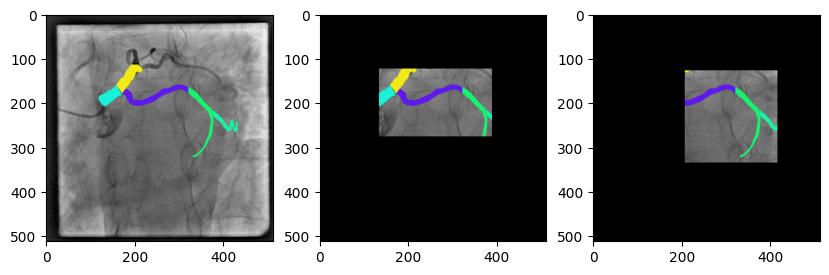

In [7]:
plt.figure(figsize=(10,10))
i=1
for data in train_images:
    img, label ,binary_label,bbox,name_stem = data
    if(name_stem=='678'):
        img=cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)
        c = colors[label[label>0]-1].reshape(-1,3)
        img[binary_label==1,:]=c
        print(binary_label.shape,np.unique(label))
        plt.subplot(3,3,i)
        plt.imshow(img)
        i+=1